## Import libraries

In [ ]:
from pathlib import Path
from torchvision.utils import make_grid
from types import SimpleNamespace
from senn.utils.stability_white_noise import *
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
from senn.models import *
from senn.models.senn import SENN
from senn.models.parameterizers import ConvParameterizer
from senn.models.conceptizers import ConvConceptizer, VaeConceptizer
from senn.models.aggregators import SumAggregator

In [2]:
plt.style.use('seaborn-v0_8-talk')

## Configuration

In [3]:
config = {
    "train": False,
    "conceptizer": "ConvConceptizer",
    "image_size": 28,
    "concept_dim": 1,
    "parameterizer": "ConvParameterizer",
    "cl_sizes": [1, 10, 20],
    "hidden_sizes": [320, 50],
    "num_concepts": 5,
    "num_classes": 10,
    "dropout": 0.5,
    "aggregator": "SumAggregator",
    "device": "cpu",
    "lr": 2e-4,
    "epochs": 20,
    "robustness_loss": "mnist_robustness_loss",
    "robust_reg": 1e-2,
    "concept_reg": 1,
    "print_freq": 100,
    "exp_name": "fashion_mnist_lambda1e-2_c5_seed29",
    "dataloader": "fashion_mnist",
    "data_path": "datasets/data/fashion_mnist_data",
    "batch_size" : 200,
    "sparsity_reg" : 2e-5,
    "eval_freq" : 270,
    "manual_seed": 29
  }
  
  
config = SimpleNamespace(**config)

## Load Trained Model

In [6]:
conceptizer = eval(config.conceptizer)(**config.__dict__)
parameterizer = eval(config.parameterizer)(**config.__dict__)
aggregator = eval(config.aggregator)(**config.__dict__)

In [7]:
model = SENN(conceptizer, parameterizer, aggregator)

In [9]:
checkpoint_path = Path('results')
model_file = checkpoint_path / config.exp_name / "checkpoints" / "best_model.pt" 
checkpoint = torch.load(model_file, map_location=config.device, weights_only=False)
print(f"Loading trained model: {model_file}")

Loading trained model: results/fashion_mnist_lambda1e-2_c5_seed29/checkpoints/best_model.pt


In [10]:
model.load_state_dict(checkpoint['model_state'])

<All keys matched successfully>

## Load data

In [11]:
from senn.datasets.dataloaders import get_dataloader
train_dl, val_dl, test_dl = get_dataloader(config)

x_b, y_b = next(iter(test_dl))

In [12]:
for images, labels in train_dl:
    print(f"Max pixel value: {images.max().item()}")
    print(f"Min pixel value: {images.min().item()}")
    break

Max pixel value: 2.022662878036499
Min pixel value: -0.8101983666419983


## Example on mini-batch

Clean pixel range: 0.0 1.0
Noisy pixel range: 0.0 1.0
Noisy normalized range: -0.8101983666419983 2.022662878036499
Pred clean: [9, 2, 1, 1, 6, 1, 6, 6]
Pred noisy: [9, 2, 1, 1, 6, 1, 6, 6]
Changed predictions: 0 / 8


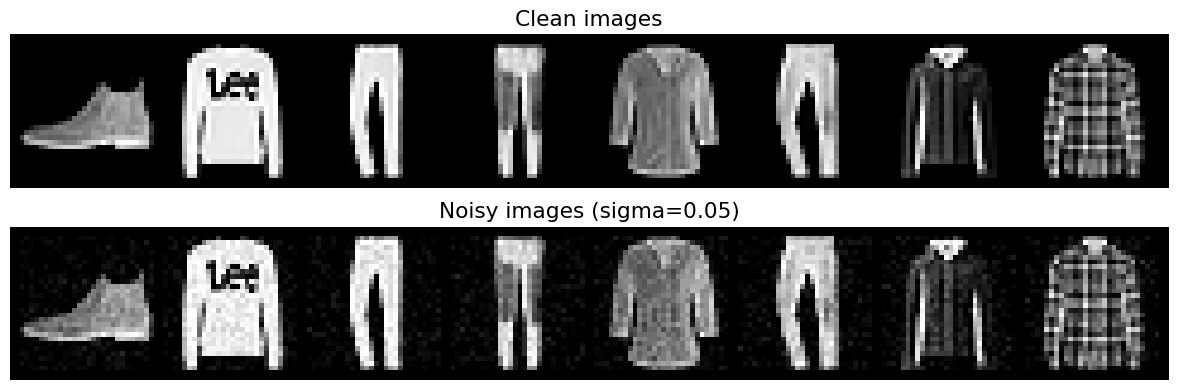

In [15]:
model.eval()
device = torch.device(config.device)

# take a small subset for visualization
x_clean_norm = x_b[:8].to(device)

# generate noisy version
sigma = 0.05 # larger -> stronger perturbation, 0.05 means if pixel value = 0.6 most noisy versions will be around 0.6 +- 0.05
x_noisy_norm, x_noisy_pix = add_white_noise(x_clean_norm, sigma=sigma)

# clean pixels for plotting
x_clean_pix = denormalize(x_clean_norm)

# sanity check ranges
print("Clean pixel range:", float(x_clean_pix.min()), float(x_clean_pix.max()))
print("Noisy pixel range:", float(x_noisy_pix.min()), float(x_noisy_pix.max()))
print("Noisy normalized range:", float(x_noisy_norm.min()), float(x_noisy_norm.max()))

# compare predictions clean vs noisy
with torch.no_grad():
    y_clean, _, _ = model(x_clean_norm)
    y_noisy, _, _ = model(x_noisy_norm)
    pred_clean = y_clean.argmax(dim=1)
    pred_noisy = y_noisy.argmax(dim=1)

print("Pred clean:", pred_clean.cpu().tolist())
print("Pred noisy:", pred_noisy.cpu().tolist())
print("Changed predictions:", int((pred_clean != pred_noisy).sum().item()), "/", x_clean_norm.size(0))

# visualize clean and noisy images (both in pixel space [0,1])
grid_clean = make_grid(x_clean_pix.cpu(), nrow=8, padding=2)
grid_noisy = make_grid(x_noisy_pix.cpu(), nrow=8, padding=2)

plt.figure(figsize=(14, 4))
plt.subplot(2, 1, 1)
plt.imshow(grid_clean.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title(f"Clean images")
plt.axis("off")

plt.subplot(2, 1, 2)
plt.imshow(grid_noisy.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title(f"Noisy images (sigma={sigma})")
plt.axis("off")

plt.tight_layout()
plt.show()